# Hypothesis Testing & EDA

## Objectives

- Carry out hypothesis testing using statistical analysis techniques.
- Carry out Thematic Analysis.
- Carry out Predicitve Analysis using Linear Regression.

## Inputs

- data/outputs/clinical_trials_no_missing_values.csv

## Outputs

- INSERT UPDATED DATASET

_________

The clinical trials dataset with no missing values will be loaded into this notebook.

The necessary libraries to conduct the analysis will be imported into this notebook.

In [1]:
# Import necessary libraries for data analysis and visualization (assistance from CoPilot)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer
import os

## Hypothesis Testing

Import the dataset as a CSV file to perform the analysis.

In [2]:
# Load the cleaned dataset 
df = pd.read_csv('../data/outputs/clinical_trials_no_missing_values.csv')
df.head()

,Unnamed: 0,Sponsor,Title,Summary,Start_Year,Start_Month,Phase,Enrollment,Status,Condition,Start_Month_Name,Start_Year_Period,Enrolled_Participants
0,0,GSK,"An Open-Label, Non-Randomized Pharmacokinetic ...",The main purpose of this study is to compare h...,2006,9,Phase 1,29,Completed,"Purpura, Thrombocytopenic, Idiopathic",September,2006-2010,<50
1,1,Sanofi,"A Randomized, Double-blind, Placebo-controlled...",Primary Objective: To evaluate the efficacy of...,2018,11,Phase 3,360,Recruiting,Giant Cell Arteritis,November,2016-2020,100-499
2,2,Pfizer,A Multi Center Randomized Cross Over Double Bl...,This is a pilot study to generate hypotheses a...,2007,3,Phase 2,27,Completed,Prostatic Hyperplasia,March,2006-2010,<50
3,3,Novartis,"A Double-blind, Randomized, Placebo-controlled...",This study will evaluate the effect of FTY720 ...,2008,9,Phase 2,36,Completed,Asthma,September,2006-2010,<50
4,4,Novartis,"A Two Part Study Including a Randomized, Doubl...",This study is designed to enable optimal dose ...,2013,8,Phase 1,93,Terminated,Hypertension,August,2011-2015,50-99


Remove duplicated index from loaded dataset.

In [3]:
# Check if 'Unnamed: 0' exists in the DataFrame and drop it
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)   
df.head()

,Sponsor,Title,Summary,Start_Year,Start_Month,Phase,Enrollment,Status,Condition,Start_Month_Name,Start_Year_Period,Enrolled_Participants
0,GSK,"An Open-Label, Non-Randomized Pharmacokinetic ...",The main purpose of this study is to compare h...,2006,9,Phase 1,29,Completed,"Purpura, Thrombocytopenic, Idiopathic",September,2006-2010,<50
1,Sanofi,"A Randomized, Double-blind, Placebo-controlled...",Primary Objective: To evaluate the efficacy of...,2018,11,Phase 3,360,Recruiting,Giant Cell Arteritis,November,2016-2020,100-499
2,Pfizer,A Multi Center Randomized Cross Over Double Bl...,This is a pilot study to generate hypotheses a...,2007,3,Phase 2,27,Completed,Prostatic Hyperplasia,March,2006-2010,<50
3,Novartis,"A Double-blind, Randomized, Placebo-controlled...",This study will evaluate the effect of FTY720 ...,2008,9,Phase 2,36,Completed,Asthma,September,2006-2010,<50
4,Novartis,"A Two Part Study Including a Randomized, Doubl...",This study is designed to enable optimal dose ...,2013,8,Phase 1,93,Terminated,Hypertension,August,2011-2015,50-99


In [4]:
# Check pandas DataFrame shape
df.shape

(9439, 12)

## Clustering

Cluster the condition column in dataset to increase accuracy of testing and enhance visualisations. Earlier investiagtion of the dataset revealled multiple similiar/same conditions have been inputted as unique entries. 

Identify the top 20 recurring conditions present in the Condition column, to increase variation and reduce bias in cluster. Identification of the top 20 recurring conditions allows for a more accurate represenation of the data.

In [5]:
# Count the occurrences of each condition
top_conditions = df['Condition'].value_counts().head(20)

# Display the top 20 recurring conditions
print("Top 20 Recurring Conditions:")
print(top_conditions)

Top 20 Recurring Conditions:
Condition
Diabetes Mellitus, Type 2                 373
Breast Neoplasms                          264
Pulmonary Disease, Chronic Obstructive    241
Arthritis, Rheumatoid                     240
Hypertension                              231
Influenza, Human                          227
Asthma                                    215
Schizophrenia                             199
Diabetes Mellitus                         189
Lung Neoplasms                            160
Alzheimer Disease                         142
Hepatitis                                 134
Psoriasis                                 131
Hypercholesterolemia                      119
HIV Infections                            109
Prostatic Neoplasms                       105
Infection                                  98
Colorectal Neoplasms                       94
Hepatitis B                                94
Anemia                                     90
Name: count, dtype: int64


All 20 conditions identified will be used to improve condition mapping during clustering.

Check distance matrix has no negative values, so clustering can be conducted.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Preprocess the Condition column
df['Condition_cleaned'] = df['Condition'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).str.strip()

# Vectorize the Condition column using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Condition_cleaned'])

# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix)

# Convert cosine similarity to a distance matrix and ensure non-negative values
distance_matrix = 1 - cosine_sim
distance_matrix = np.clip(distance_matrix, 0, None)  # Clip negative values to 0

# Debug: Check distance matrix range
print("Minimum value in distance matrix:", distance_matrix.min())
print("Maximum value in distance matrix:", distance_matrix.max())

Minimum value in distance matrix: 0.0
Maximum value in distance matrix: 1.0


In [9]:
print("Minimum value in distance matrix:", distance_matrix.min())
print("Maximum value in distance matrix:", distance_matrix.max())

Minimum value in distance matrix: 0.0
Maximum value in distance matrix: 1.0


In [10]:
distance_matrix = np.clip(distance_matrix, 0, None)  # Clip negative values to 0

Check cosine similarity matrix has no negative values, so clustering can be conducted.

In [11]:
print("Minimum value in cosine similarity matrix:", cosine_sim.min())
print("Maximum value in cosine similarity matrix:", cosine_sim.max())

Minimum value in cosine similarity matrix: 0.0
Maximum value in cosine similarity matrix: 1.0000000000000004


Preprocess the text to ready the data for clustering. Apply DBSCAN clustering to group condtions into clusters. Map clusters by assigning a cluster label to each condition.

In [12]:
clustering_model = DBSCAN(eps=1.4, min_samples=2, metric='precomputed')

Conduct clustering on the Condition column.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
import numpy as np

# Preprocess the Condition column
df['Condition_cleaned'] = df['Condition'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).str.strip()

# Vectorize the Condition column using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Condition_cleaned'])

# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix)

# Debug: Check cosine similarity range
print("Minimum value in cosine similarity matrix:", cosine_sim.min())
print("Maximum value in cosine similarity matrix:", cosine_sim.max())

# Convert cosine similarity to a distance matrix and ensure non-negative values
distance_matrix = 1 - cosine_sim
distance_matrix = np.clip(distance_matrix, 0, None)  # Clip negative values to 0

# Debug: Check distance matrix range
print("Minimum value in distance matrix:", distance_matrix.min())
print("Maximum value in distance matrix:", distance_matrix.max())

# Apply DBSCAN clustering
clustering_model = DBSCAN(eps=1.4, min_samples=2, metric='precomputed')
clusters = clustering_model.fit_predict(distance_matrix)  # Use the corrected distance matrix

# Add cluster labels to the DataFrame
df['Condition_cluster'] = clusters

# Display the clustered conditions
clustered_conditions = df[['Condition', 'Condition_cluster']].sort_values(by='Condition_cluster')
print(clustered_conditions)

Minimum value in cosine similarity matrix: 0.0
Maximum value in cosine similarity matrix: 1.0000000000000004
Minimum value in distance matrix: 0.0
Maximum value in distance matrix: 1.0
                                       Condition  Condition_cluster
0          Purpura, Thrombocytopenic, Idiopathic                  0
6288                              Lung Neoplasms                  0
6289                         Depressive Disorder                  0
6290                                      Asthma                  0
6291  Sleep Initiation and Maintenance Disorders                  0
...                                          ...                ...
3147                   Diabetes Mellitus, Type 2                  0
3148                          Dermatitis, Atopic                  0
3149              Carcinoma, Non-Small-Cell Lung                  0
3133                    Urinary Tract Infections                  0
9438                              Osteoarthritis                  0

Define the labels of each cluster by manually grouping conditions based on common keywords.

In [14]:
# Define a mapping of keywords to groups
condition_mapping = {
    'diabetes mellitus': 'Diabetes',
    'breast neoplasms': 'Breast Cancer',  
    'chronic obstructive pulmonary disease': 'COPD',
    'rheumatoid arthritis': 'Rheumatoid Arthritis',
    'hypertension': 'Hypertension',
    'human influenza': 'Influenza',
    'asthma': 'Asthma',
    'schizophrenia': 'Schizophrenia',
    'diabetes mellitus type 2': 'Diabetes',
    'lung neoplasms': 'Lung Cancer',
    'alzheimer disease': 'Alzheimer\'s Disease',
    'hepatitis': 'Hepatitis',
    'psoriasis': 'Psoriasis',
    'hypercholesterolemia': 'Hypercholesterolemia',
    'hiv infections': 'HIV Infections',
    'prostatic neoplasms': 'Prostate Cancer',
    'infections': 'Infections',
    'colorectal neoplasms': 'Colorectal Cancer',
    'hepatitis b': 'Hepatitis B',
    'anemia': 'Anemia',
    

    # Add more keywords and groups as needed
}

# Map conditions to groups
def map_condition(condition):
    for keyword, group in condition_mapping.items():
        if keyword in condition:
            return group
    return 'Other'

df['Condition_grouped'] = df['Condition_cleaned'].apply(map_condition)

Check the number of unique condtions present in the new column ('Condition_grouped').

In [15]:
num_unique = df['Condition_grouped'].nunique()
print(num_unique)

16


Check the names of each unique condition in new column.

In [16]:
print(df['Condition_grouped'].unique())

['Other' 'Asthma' 'Hypertension' 'Psoriasis' 'Breast Cancer' 'Diabetes'
 'Hepatitis' 'Infections' 'Anemia' 'Hypercholesterolemia' 'Schizophrenia'
 'Colorectal Cancer' 'HIV Infections' 'Lung Cancer' "Alzheimer's Disease"
 'Prostate Cancer']


DBSCAN is a powerful clustering algorithm for data with complex shapes, nois and unknown cluster numbers, which suits this dataset. Condition_grouped will be used to carry out hypothesis testing, qualitative analysis and visualisations.

_______

## **Hypothesis 1:** Using a Chi-Squared Test

Testing to see if the number of clinical trials for a specific condition has increased over the years.

- **Null Hypothesis (H₀):** The number of clinical trials for a specific condition has not increased over the years (no association between Condition and Year).

- **Alternative Hypothesis (H₁):** The number of clinical trials for a specific condition has increased over the years (there is an association between Condition and Year).

In [17]:
from scipy.stats import chi2_contingency

# CoPilot code creation
# Step 1: Create a contingency table
contingency_table = pd.crosstab(df['Condition_grouped'], df['Start_Year'])
# Display the contingency table
print("Contingency Table:")
print(contingency_table.head())

# Step 2: Perform the Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Step 3: Display the results
print("Chi-Squared Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)

# Step 4: Interpret the results
alpha = 0.05  # Significance level
if p < alpha:
    print("Reject the null hypothesis: There is an association between Condition and Year.")
else:
    print("Fail to reject the null hypothesis: No association between Condition and Year.")

Contingency Table:
Start_Year           1984  1985  1988  1989  1990  1992  1993  1994  1995  \
Condition_grouped                                                           
Alzheimer's Disease     0     0     0     0     0     0     0     0     0   
Anemia                  0     0     1     0     0     0     0     0     1   
Asthma                  0     0     0     0     0     0     0     0     0   
Breast Cancer           0     0     0     0     0     0     0     0     0   
Colorectal Cancer       0     0     0     0     0     0     0     0     0   

Start_Year           1996  ...  2011  2012  2013  2014  2015  2016  2017  \
Condition_grouped          ...                                             
Alzheimer's Disease     0  ...     9     9     3     4     4     4     3   
Anemia                  1  ...     1     2     3     8     3     6     5   
Asthma                  0  ...     9    16     8    11    12     8    13   
Breast Cancer           0  ...    11    14    20    17    18 

The p-value can never be greater than 1, the reported p-value needs to be calculated:

5.35 × 10⁻¹⁶ = 0.000000000000000535

Reject the null hypothesis as the p-value is largely below 0.05 indicating, there is a strong statistically significant relationship between the medical condition being studied and year of the study. 

There has been a significant increase in the number of clincial trials conducted over the years for conditions such as Breast Cancer and Alzheimer's Disease. Which could be down to changes in research priorities, advances in medical technology, funding or public health concerns.

Future Analysis - Investigate why there has been a peak in certain conditions over the years such as disease outbreaks. Additionally, investigate if the conditions have been under researched & conduct clinical trials on the least represented conditions.

## Hypothesis 2: Using a Mann-Whitney U Test

Testing to see if trials with higher enrolled participants are more likely to reach 'Completed' status.

- **Null Hypothesis (H₀):** There is no difference in the number of enrolled participants between trials with 'Completed' status over other statuses.

- **Alternative Hypothesis (H₁):** Trials with "Completed" status have a higher number of enrolled participants compared to other statuses.

In [18]:
from scipy.stats import mannwhitneyu

# CoPilot code creation
# Step 1: Split the data into two groups
completed_trials = df[df['Status'] == 'Completed']['Enrollment']
other_trials = df[df['Status'] != 'Completed']['Enrollment']

# Step 2: Perform the Mann-Whitney U Test
stat, p = mannwhitneyu(completed_trials, other_trials, alternative='greater')

# Step 3: Display the results
print("Mann-Whitney U Statistic:", stat)
print("P-Value:", p)

# Step 4: Interpret the results
alpha = 0.05  # Significance level
if p < alpha:
    print("Reject the null hypothesis: Trials with 'Completed' status have higher enrollment.")
else:
    print("Fail to reject the null hypothesis: No significant difference in enrollment.")

Mann-Whitney U Statistic: 8397319.5
P-Value: 1.8562410266235526e-14
Reject the null hypothesis: Trials with 'Completed' status have higher enrollment.


The p-value can never be greater than 1, the reported p-value needs to be calculated:

1.86 × 10⁻¹⁴ = 0.000000000000018562410266235526

Reject the null hypothesis as the p-value is largely below 0.05, indicating there is a strong statistically significant relationship between the high number of enrollment and the Clinical Trials reaching 'Completed' status.

Trials marked as 'Completed' often enroll a higher number of participants. Which suggets the sponsors may deem this as a higher level of commitment by particpants, and are more inclined to continue funding as there is less risk associated. 

Future Improvements:

Most clinical trials are funded in stages or milestones, so researches should prioritise high enrollment numbers for Clinical Trials studies to improve the chance of the trial being comleted to full term. Additionally, the terms contract put in place with the sponsors can be negotiated to account for lower enrollment numbers.

## Hypothesis 3: Using Chi-Squared Test

Testing to see if the number of clinical trials is independent of the sponsor

- **Null Hypothesis (H₀):** The number of clinical trials is independent of the sponsor (no association between Sponsor and Condition_grouped).

- **Alternative Hypothesis (H₁):** The number of clinical trials is not independent of the sponsor (there is an association between Sponsor and Condition_grouped).

In [19]:
from scipy.stats import chi2_contingency

# CoPilot code creation
# Step 1: Create a contingency table
contingency_table = pd.crosstab(df['Sponsor'], df['Condition_grouped'])

# Display the contingency table
print("Contingency Table:")
print(contingency_table.head())

# Step 2: Perform the Chi-Squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Step 3: Display the results
print("Chi-Squared Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)

# Step 4: Interpret the results
alpha = 0.05  # Significance level
if p < alpha:
    print("Reject the null hypothesis: The number of clinical trials is not independent of the sponsor.")
else:
    print("Fail to reject the null hypothesis: The number of clinical trials is independent of the sponsor.")

Contingency Table:
Condition_grouped  Alzheimer's Disease  Anemia  Asthma  Breast Cancer  \
Sponsor                                                                 
AbbVie                               7       0       1              5   
Bayer                                2       6       0              8   
GSK                                 17      14      87             27   
Gilead                               0       0       0              0   
JNJ                                 18      19       4              5   

Condition_grouped  Colorectal Cancer  Diabetes  HIV Infections  Hepatitis  \
Sponsor                                                                     
AbbVie                             4         0               0         33   
Bayer                              7         6               1          0   
GSK                                4        81              27         91   
Gilead                             0         6              28         75   
JNJ    

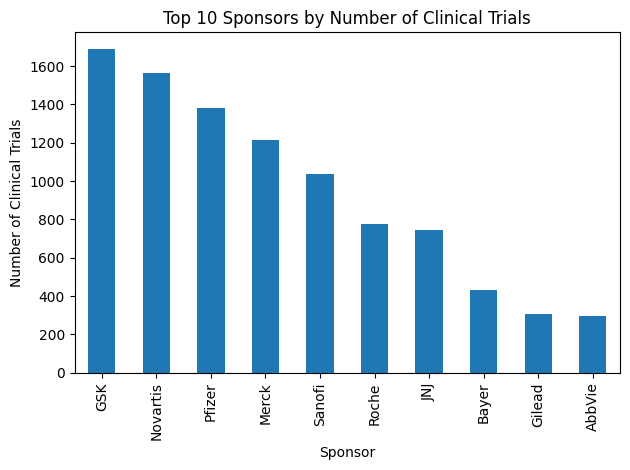

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# CoPilot code creation
#  Plotting the top 10 sponsors by number of clinical trials
sponsor_counts = df['Sponsor'].value_counts().head(10)
sponsor_counts.plot(kind='bar')
plt.xlabel('Sponsor')
plt.ylabel('Number of Clinical Trials')
plt.title('Top 10 Sponsors by Number of Clinical Trials')
plt.tight_layout()
plt.show()


Reject the null hypothesis as the p-value is 0.00, indicating it is extremely statistically significant. 

The bar plot shows that there a significantlly higher distribution of clinical trials being carried out by particluar sponsors such as GSK, Novartis and Pfizer.
This could be due to the sponsors being larger pharmaceutical companies with access to more capital for funding.

Future Improvements:

Diversifying the represenataion of sponsors could bring fresh perspectives and innovation to the research, building on partnerships with those less represented in the bar plot will be beneficial.

Additionally, reducuing the concentration of clinical trials among a few sposnosrs could reduce systemic risk. Reducing the number of major sponsor withdraws.

Save the dataset with clustered conditions for visualisation purposes in Tableau.

In [21]:
# Save the DataFrame 
output_dir = '../data/outputs'
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
df.to_csv(f'{output_dir}/clinical_trials_clustered.csv', index=True)

print("Clustered Dataset saved successfully!")

Clustered Dataset saved successfully!


_________

## Statistical Analysis - Logistic Regression

Encoded dataset loaded into DataFrame to conduct Logistic Regression.

In [59]:
# Load the encoded dataset 
df = pd.read_csv('../data/outputs/encoded_clinical_trials.csv')

# Display the first row of the DataFrame
df.head(1)

,index,Title,Summary,Start_Year,Start_Month,Phase,Enrollment,Status,Condition,Start_Month_Name,...,Sponsor_Bayer,Sponsor_GSK,Sponsor_Gilead,Sponsor_JNJ,Sponsor_Merck,Sponsor_Novartis,Sponsor_Pfizer,Sponsor_Roche,Sponsor_Sanofi,Status_Encoded
0,8746,"An Open-Label, Non-Randomized Pharmacokinetic ...",The main purpose of this study is to compare h...,2006,9,Phase 1,29,Completed,"Purpura, Thrombocytopenic, Idiopathic",September,...,False,True,False,False,False,False,False,False,False,1


Conduct time series analysis for further insights by conducting a linear regression of Start_Year and Status_Encoded.

In [64]:
# Copilot code creation
# Features and target
X = df[['Start_Year'] + [col for col in df.columns if 'Status_Encoded' in col]]
y = df['Status_Encoded']  # Replace with your target column

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 5.498294626686134e-28


Plot linear regression in a scatter plot visualisation.

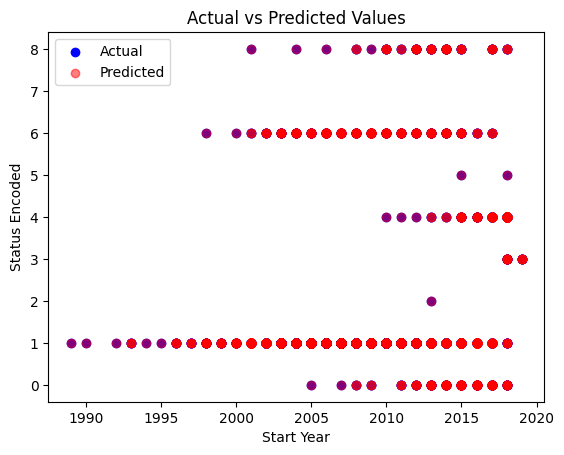

In [63]:
# assist with CoPilot 
plt.scatter(X_test['Start_Year'], y_test, color='blue', label='Actual')
plt.scatter(X_test['Start_Year'], y_pred, color='red', label='Predicted', alpha=0.5)
plt.xlabel('Start Year')
plt.ylabel('Status Encoded')
plt.legend()
plt.title('Actual vs Predicted Values')
plt.show()

For certain years there is close alignment of actual and predicted values, where the blue and red points overlap. Which indicates the model performs well for some but struggles for others. 

Future Improvements:
 Change the feature of the model to improve predictions. 

Plot residuals in a scatter plot to display the difference between actual and predicted values, to help identify patterns in predicition errors.

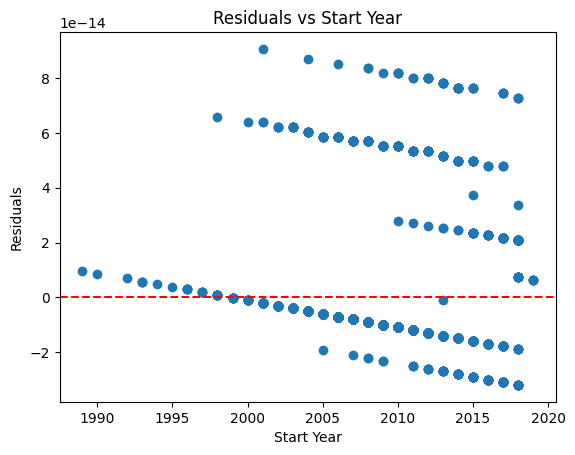

In [62]:
# Copilot code creation
# Plot residuals in a scatter plot 
residuals = y_test - y_pred
plt.scatter(X_test['Start_Year'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Start Year')
plt.ylabel('Residuals')
plt.title('Residuals vs Start Year')
plt.show()